
 <center> <h1> <b> Pattern Recognition and Machine Learning (EE2802 - AI2000) </b> </h1> </center>

<b> Programming Assignment 01 - KNN : </b> Welcome to the programming assignment (PA) on k-nearest neighbors (KNN) classification. Throughout this PA, you will explore the k-NN algorithm, a versatile and intuitive method for tackling classification and regression challenges. Specifically, this assignment aims to enhance your understanding of the KNN classification algorithm. In this PA, we expect you to implement and experiment with the KNN classifier to understand how variations in 'k' and distance metrics influence classification performance.

<b> Instructions </b>
1. Plagiarism is strictly prohibited.
2. Delayed submissions are not accepted
3. Please DO NOT use any machine learning libraries unless and otherwise specified.



<b> Part(a): Synthetic data generation </b>  

1. Consider four bivariate Gaussians with means at (0,0), (0,1), (1,0), and (1,1), each with a diagonal covariance matrix with diagonal elements being 0.1. Sample 90 points from each Gaussian, resulting in a total of 360 points. Allocate 30 points from each Gaussian for training and 60 points for testing. This results in a total of 120 points for training and 240 points for testing.

2. Create a 2-class training set ($[X_{train}, Y_{train}]$) and a test set ($[X_{test}, Y_{test}]$) by labeling the data sampled from Gaussians with means at (0,0) and (1,1) as class 1, and the data sampled from Gaussians with means at (0,1) and (1,0) as class 2. Assign a label of +1 to class1 and -1 to class2.

4. Visualize both train and test sets using the scatter plot on a 2-D plane. Indicate the data points from class 1 with a green color and those from class 2 with a blue color.

<b> Part(b): KNN Classification - </b> The k-Nearest Neighbors (KNN) classifier algorithm is a straightforward yet powerful tool for classification tasks. The KNN classifier takes the test data point, computes distances to all points in the training set, identifies the 'k' nearest neighbors based on these distances, and assigns the test data to the class that the majority of its neighbors belong to.

<b> Programming questions </b>


1. Develop a Python class named 'KNeighbourClassifier' that encapsulates the hyperparameters of a K-Nearest Neighbors (KNN) classifier, such as the number of neighbors (k) and the distance metric. Implement the following methods within this class. $\textit{fit(X_train, y_train):}$ This method should accept training data (X_train) and corresponding labels (y_train) as input. It should store these inputs as internal attributes of the class for later use in prediction. $\textit{predict(X_test):} This method should take test data (X_test) as input and return the predicted labels for the given data points using the KNN algorithm.

2. Instantiate an object of the KNeighbourClassifier class. Train the classifier on the provided training data by calling the fit() method. Use this trained classifier to predict the labels of the test data. Finally, evaluate the classifier's accuracy by comparing the predicted labels with the actual (original) labels of the test data

3. Generate a 2D scatter plot of the test data, assigning green to class 1, blue to class 2, and red to test data points whose predicted labels do not match their true labels.

4. Visualize the decision boundaries of a given classifier by generating a 2D grid and predicting the class labels for each point in the grid using the KNN algorithm. Color-code the grid points based on their predicted class labels to visually represent the decision regions

<b> Part(c): Parameter selection: What is good value for k? - </b> A common approach to finding the optimal value for the hyperparameter 'k' in K-Nearest Neighbors is through cross-validation. In this method, a portion (ρ%) of the training data is set aside as a validation set. The KNN model is then trained on the remaining data and evaluated on the validation set for a range of 'k' values. The optimal 'k' is selected as the value that results in the best performance on the validation set.

<b> Algorithm </b>

1. Perform hold-out cross-validation by setting aside a fraction (ρ of the training set for validation. Note: You may use ρ = 0.3, and repeat the procedure 10 times. The hold-out procedure may be quite unstable.
2. Use a large range of candidate values for k (e.g. k = 1, 3, 5..., 21). Notice odd numbers are considered to avoid ties.
3. Repeat the process for 10 times using a random cross-validation set each time with a ρ = 0.3.
4. Plot the training and validation errors for the different values of k.

<b> Questions </b>

5. How would you now answer the question "what is the best value for k"?
6. How is the value of k affected by ρ (percentage of points held out) and number of repetitions? What does a large number of repetitions provide?
7. Apply the model obtained by cross-validation (i.e., best k) to the test set and check if there is an improvement on the classification error over the result of Part (b).

<b> Part(d): Influence of training data on KNN classifier - </b>

1. Evaluate the performance as the size of the training set
grows, e.g., n = {200, 400, 1200,...}. How would you choose a good range for k as n changes? What can you say about the stability of the solution? Check by repeating the validation multiple times.

2. Investigate how the distribution of the training data affects the performance of the KNN algorithm. Replace the Gaussian distribution used in part (a) with a Laplacian distribution. Generate both training and testing datasets based on these distributions. Evaluate the KNN classifier's performance on both datasets. Analyze whether the KNN achieves comparable performance with both Gaussian and Laplacian distributed data. Examine the effect of changing the distance metric from $l_{2}$ to $l_{1}$ on the KNN performance for both Gaussian and Laplacian distributed datasets


<b> Part(e): What is the influence of distance measure on decision regions ? - </b>

1. Evaluate the performance of the KNN classifier with different distance measures such as $l_{1}$, $l_{2}$, etc,.
2. Plot the decision regions of the KNN classifier with different distance measures.
3. Report your observations.  

<b> Part(f): MNIST Digit classification using KNN classifier: </b> :

1. Use the above written KNN classifier to perform digit claissification using MNIST digit dataset.
2. The MNIST dataset consists of approximately 70,000 images of handwritten digits. Create training, validation, and test datasets from this entire dataset with the respective proportions of 80%, 10%, and 10%. The 28x28 images in the MNIST data set may be flattened to arrive at a 784 dimensional vector.
3. Use the most suitable distance metric and k to maximize the test data performance.
4. Create a confusion matrix to understand the most confused classes (digits).
5. Suggest alternate ways to improve the performance.



Most of the finishing plotting codes and some algorithms have been assisted by GitHub copilot  

In [ ]:
#All imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import math
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

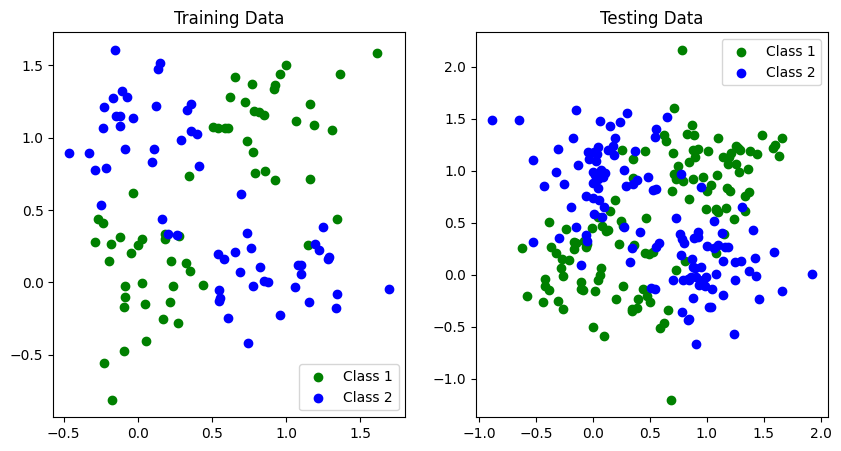

In [ ]:
########################################
#Part(a) #Synthetic data generation
########################################
#Define means and covariances

means = [[0, 0], [0, 1], [1, 0], [1, 1]]

cov = [[0.1, 0], [0, 0.1]]

#Sample data points from the bivariate Gaussian distribution


#You can use "np.random.multivariate_normal" function to sample the data points from the multivariate Gaussian distribution
training_testcases = 30
testing_testcases = 60

train_data = [np.random.multivariate_normal(mean, cov, training_testcases) for mean in means]
test_data = [np.random.multivariate_normal(mean, cov, testing_testcases) for mean in means]


#Generate training data
Xtrain = np.concatenate((train_data[0], train_data[3], train_data[1], train_data[2]))
Ytrain = np.concatenate((np.ones(training_testcases * 2), -np.ones(training_testcases * 2)))

# Combine testing data
Xtest = np.concatenate((test_data[0], test_data[3], test_data[1], test_data[2]))
Ytest = np.concatenate((np.ones(testing_testcases * 2), -np.ones(testing_testcases * 2)))

# Visualize training and testing data
plt.figure(figsize=(10, 5))

# Training data plot
plt.subplot(1, 2, 1)
plt.scatter(train_data[0][:, 0], train_data[0][:, 1], color='green', label='Class 1')
plt.scatter(train_data[3][:, 0], train_data[3][:, 1], color='green')
plt.scatter(train_data[1][:, 0], train_data[1][:, 1], color='blue', label='Class 2')
plt.scatter(train_data[2][:, 0], train_data[2][:, 1], color='blue')
plt.title('Training Data')
plt.legend()

# Testing data plot
plt.subplot(1, 2, 2)
plt.scatter(test_data[0][:, 0], test_data[0][:, 1], color='green', label='Class 1')
plt.scatter(test_data[3][:, 0], test_data[3][:, 1], color='green')
plt.scatter(test_data[1][:, 0], test_data[1][:, 1], color='blue', label='Class 2')
plt.scatter(test_data[2][:, 0], test_data[2][:, 1], color='blue')
plt.title('Testing Data')
plt.legend()

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

########################################
#Part(b) #KNN classification
########################################

#Write "kNNClassify" function
class KNeighborsClassifier:
    def __init__(self, n_neighbors=5, distance_metric="l2"):
        self.n_neighbors = n_neighbors
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, Y_train):
        self.X_train = X_train
        self.y_train = Y_train

    def predict(self, X_test):
        predictions = []
        for test_point in X_test:
            if self.distance_metric == "l2":
                distances = np.sqrt(np.sum((self.X_train - test_point) ** 2, axis=1))
            elif self.distance_metric == "l1":
                distances = np.sum(np.abs(self.X_train - test_point), axis=1)
            else:
                raise ValueError("Unsupported distance metric. Choose 'l1' or 'l2'.")

            nearest_indices = np.argsort(distances)[:self.n_neighbors]
            nearest_labels = self.y_train[nearest_indices]
            label = np.sign(np.sum(nearest_labels))
            predictions.append(label)

        return np.array(predictions)

#Write "KNNAccuracy" function
def KNNAccuracy(true, pred):
    return np.mean(true == pred)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xtrain, Ytrain)
y_pred = knn.predict(Xtest)

accuracy = KNNAccuracy(Ytest, y_pred)
print(f'KNN Model Accuracy: {accuracy * 100:.2f}%')

#Create a visual representation of predictions
plt.figure(figsize=(8, 6))
plt.scatter(Xtest[Ytest == 1][:, 0], Xtest[Ytest == 1][:, 1], color='green', label='Class 1')
plt.scatter(Xtest[Ytest == -1][:, 0], Xtest[Ytest == -1][:, 1], color='blue', label='Class 2')
misclassified = (Ytest != y_pred)
plt.scatter(Xtest[misclassified][:, 0], Xtest[misclassified][:, 1], color='red', marker='x', label='Misclassified')
plt.legend()
plt.title('KNN Classification Results')
plt.show()

#Generate and visualize the decision regions and overlay the test points

x_min, x_max = Xtrain[:, 0].min() - 0.5, Xtrain[:, 0].max() + 0.5
y_min, y_max = Xtrain[:, 1].min() - 0.5, Xtrain[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.contour(xx, yy, Z, colors='black', linewidths=0.5)
plt.scatter(Xtrain[Ytrain == 1][:, 0], Xtrain[Ytrain == 1][:, 1], color='green', label='Class 1')
plt.scatter(Xtrain[Ytrain == -1][:, 0], Xtrain[Ytrain == -1][:, 1], color='blue', label='Class 2')
plt.title('KNN Decision Boundary')
plt.legend()
plt.show()

NameError: name 'Xtrain' is not defined

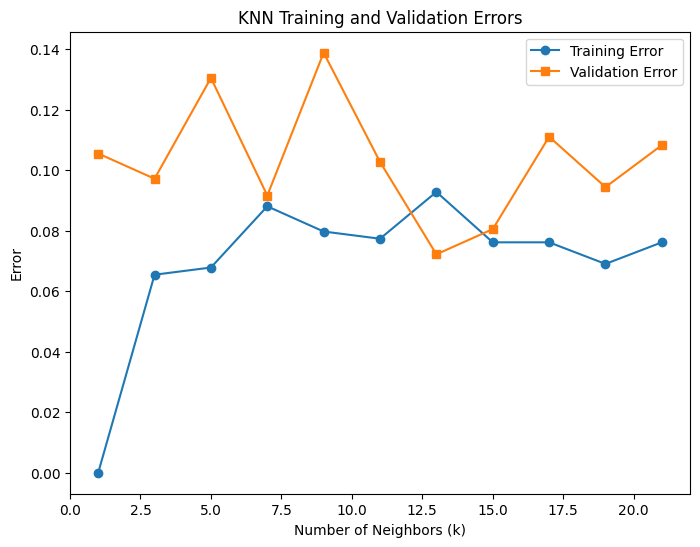

Best k value: 13
KNN Model Accuracy with Best k: 83.75%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

####################################
#Part(c): Parameter selection: What is good value for k?
####################################
#Write holdoutCVkNN() Function
def holdoutCVkNN(k_range, rho, X_train, Y_train, repetitions=10):
    train_errors = []
    val_errors = []

    #Iterate through range of k values
    for k in k_range:
        train_error = 0
        val_error = 0

        #Hold out rho fraction of training data in each repetition.
        for i in range(repetitions):
            indices = np.arange(len(X_train))
            np.random.shuffle(indices)
            split = int(len(X_train) * (1 - rho))
            train_idx, val_idx = indices[:split], indices[split:]

            X_train_fold, Y_train_fold = X_train[train_idx], Y_train[train_idx]
            X_val_fold, Y_val_fold = X_train[val_idx], Y_train[val_idx]

            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train_fold, Y_train_fold)

            train_pred = knn.predict(X_train_fold)
            val_pred = knn.predict(X_val_fold)

            train_error += 1 - KNNAccuracy(Y_train_fold, train_pred)
            val_error += 1 - KNNAccuracy(Y_val_fold, val_pred)

        #Return errors on training and validation data
        train_errors.append(train_error / repetitions)
        val_errors.append(val_error / repetitions)

    return train_errors, val_errors

#Plot training and validation errors for different values of k
k_values = np.arange(1, 22, 2)
rho = 0.3
train_errors, val_errors = holdoutCVkNN(k_values, rho, Xtrain, Ytrain)

plt.figure(figsize=(8, 6))
plt.plot(k_values, train_errors, marker='o', label='Training Error')
plt.plot(k_values, val_errors, marker='s', label='Validation Error')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error')
plt.legend()
plt.title('KNN Training and Validation Errors')
plt.show()

#what is the best value for k?
best_k = k_values[np.argmin(val_errors)]
print(f'Best k value: {best_k}')

#Effect of rho on k
# Higher rho  model is trained on fewer samples, leading to more variability in k selection.
# Lower rho provides more stable k selection as there are many samples,but if it too low it may not generalize well.
# A balanced rho (e.g., around 0.3) helps ensure a good trade-off between having enough training data for learning and enough validation data for a good vlaue of k selection

#Evaluate the performance on test set with the best hyper parameters ( i.e best k ).
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(Xtrain, Ytrain)
y_pred_best = knn_best.predict(Xtest)
best_accuracy = KNNAccuracy(Ytest, y_pred_best)
print(f'KNN Model Accuracy with Best k: {best_accuracy * 100:.2f}%')


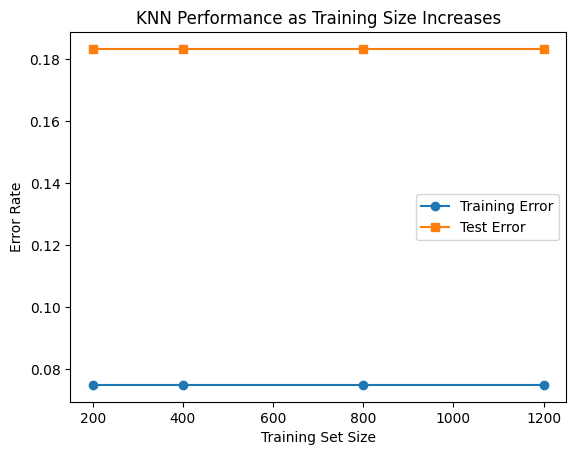

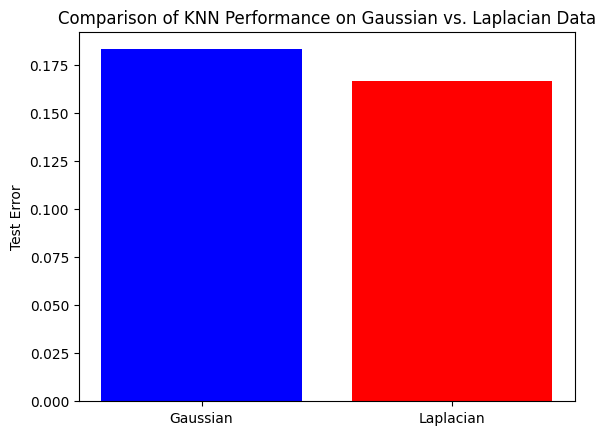

In [ ]:
##################################
#Part(d): Influence of training data on KNN classifier
##################################
#Performance evaluation as n increases







#Performance evaluation with different data distributions, i.e., Gaussian, Laplacian





In [ ]:
##################################
#Part(e): Influence of distance metric on KNN classifier
##################################
#Performance evaluation of KNN classifier with different distance metric






#Understand the decision regions of KNN classifier with different distance metric







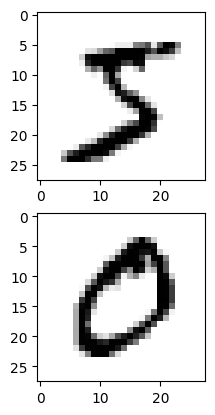

k: 3, metric: euclidean, accuracy: 0.9704


In [ ]:
##################################
# Part(f): MNIST Digit classification using KNN classifier
##################################

# Load MNIST data
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import seaborn as sns

mnist = fetch_openml('mnist_784', version=1)
images = mnist.data.to_numpy()
targets = mnist.target.astype(int).to_numpy()

# Plot a few images
plt.subplot(211)
plt.imshow(images[0].reshape(28, 28), cmap=plt.cm.gray_r, interpolation='nearest')
plt.subplot(212)
plt.imshow(images[1].reshape(28, 28), cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

# Create train, validation, and test splits
X_train, X_temp, y_train, y_temp = train_test_split(images, targets, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Write 'MultiClassKNNClassify' function
def MultiClassKNNClassify(X_train, y_train, X_val, y_val, k_values, distance_metrics):
    best_k = None
    best_metric = None
    best_accuracy = 0

    for k in k_values:
        for metric in distance_metrics:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
            knn.fit(X_train, y_train)
            y_pred = knn.predict(X_val)
            acc = accuracy_score(y_val, y_pred)
            print(f'k: {k}, metric: {metric}, accuracy: {acc:.4f}')

            if acc > best_accuracy:
                best_accuracy = acc
                best_k = k
                best_metric = metric

    return best_k, best_metric, best_accuracy

# Empirically choose the most suitable k and distance metric based on cross-validation
k_values = [3, 5, 7, 9]
distance_metrics = ['euclidean', 'manhattan', 'chebyshev']
best_k, best_metric, best_accuracy = MultiClassKNNClassify(X_train, y_train, X_val, y_val, k_values, distance_metrics)
print(f'Best k: {best_k}, Best Metric: {best_metric}, Best Accuracy: {best_accuracy:.4f}')

# Evaluate the performance on test data with the best hyperparameters obtained from cross-validation
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_best.fit(X_train, y_train)
y_test_pred = knn_best.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Test Accuracy: {test_accuracy:.4f}')

# Create a confusion matrix for test data
def compute_confusion_matrix(true, pred):
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
    return cm

cm = compute_confusion_matrix(y_test, y_test_pred)

# Suggest alternative ways to improve performance
print("\nAlternative ways to improve performance:")
print("1. Feature Scaling: Normalize or standardize pixel values for better distance metric performance.")
print("2. Dimensionality Reduction: Use PCA to reduce noise and computational complexity.")
print("3. More Training Data: Augment the dataset with variations like rotation, scaling, and shifting.")
print("4. Use Advanced Classifiers: Consider using SVM, CNNs, or Random Forest for better performance.")
print("5. Hyperparameter Tuning: Perform more exhaustive grid search with a wider range of hyperparameters.")

<b> Report your observations </b>
1. Write down the best accuracy on synthetic test data generated from Gaussian distribution

2. Write down the best accuracy on MNIST validation and test data.

3. Report your observations on the confusion matrix of KNN classifier on MNIST test data
